**Goal:** Visualize the difference between **Batch GD**, **SGD**, and **Mini-batch GD**.

**Steps:**
1.  Generate a synthetic regression dataset using `sklearn.datasets.make_regression`.
2.  Implement a simple Linear Regression class with a `fit` method that accepts a `batch_size` parameter.
3.  Run three experiments:
    *   Batch size = All data (Batch GD).
    *   Batch size = 1 (SGD).
    *   Batch size = 32 (Mini-batch).
4.  Plot the Loss vs. Epochs for all three on the same graph.
5.  **Observation to make:** Which one converges fastest? Which one has a noisy (jittery) loss curve?

Generate synthetic regression dataset

In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
X, y = make_regression(n_samples=1000, n_features=1, noise=10, random_state=42)

# add a bias term
X = np.c_[np.ones(X.shape[0]), X]
y = y.reshape(-1, 1)

Linear regression class

In [4]:
class LinearRegression:
  def __init__(self, learning_rate = 0.01, max_epochs=1000, tol=1e-4):
    self.learning_rate = learning_rate
    self.max_epochs = max_epochs
    self.tol = tol # tolerance for early stopping
    self.weights = None
    self.loss_history = []

  def fit(self, X, y, batch_size=None):
    n_samples, n_features = X.shape
    self.weights = np.zeros((n_features, 1))
    for epoch in range(self.max_epochs):
      # shuffle data at the start of each epoch
      indices = np.random.permutation(n_samples)
      X_shuffled = X[indices]
      y_shuffled = y[indices]
      if batch_size is None or batch_size == n_samples:
        # Batch GD: Use all data
        X_batch = X_shuffled
        y_batch = y_shuffled
      else:
        # SGD or Mini-batch GD
        batch_indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X_shuffled[batch_indices]
        y_batch = y_shuffled[batch_indices]
      # prediction and error
      y_pred = X_batch @ self.weights
      error = y_pred - y_batch
      # compute gradient
      gradient = (X_batch.T @ error) / len(X_batch)
      # update weights
      self.weights -= self.learning_rate * gradient
      y_pred_full = X @ self.weights
      loss = np.mean((y_pred_full - y) ** 2)
      self.loss_history.append(loss)
      if epoch > 0 and abs(self.loss_history[-2] - loss) < self.tol:
        break

    def predict(self, X):
      return X @ self.weights

Run different batches

In [6]:
batch_gd = LinearRegression(learning_rate=0.01, max_epochs=1000, tol=1e-4)
sgd = LinearRegression(learning_rate=0.01, max_epochs=1000, tol=1e-4)
mini_batch_gd = LinearRegression(learning_rate=0.01, max_epochs=1000, tol=1e-4)

batch_gd.fit(X, y, batch_size=len(X))
sgd.fit(X, y, batch_size=1)
mini_batch_gd.fit(X, y, batch_size=32)

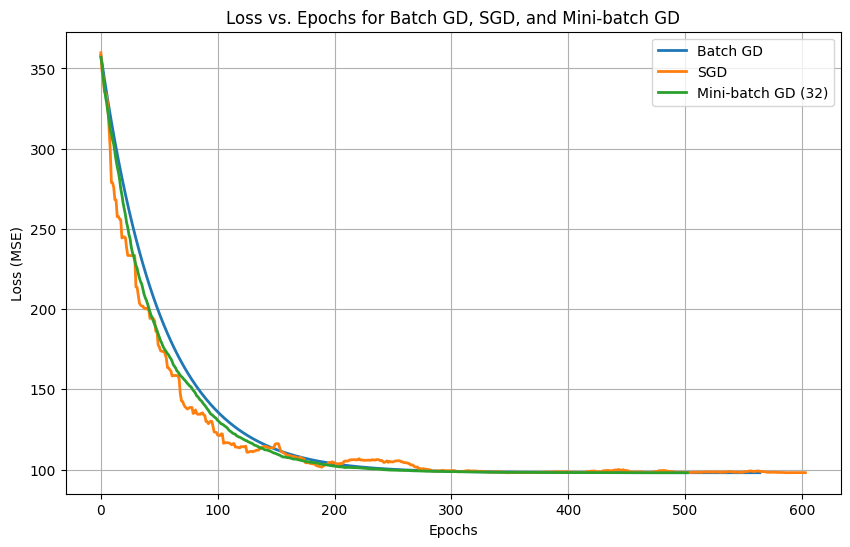

In [7]:
import matplotlib.pyplot as plt

# Plot loss vs. epochs
plt.figure(figsize=(10, 6))
plt.plot(batch_gd.loss_history, label="Batch GD", linewidth=2)
plt.plot(sgd.loss_history, label="SGD", linewidth=2)
plt.plot(mini_batch_gd.loss_history, label="Mini-batch GD (32)", linewidth=2)

# Add labels and legend
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs. Epochs for Batch GD, SGD, and Mini-batch GD")
plt.legend()
plt.grid(True)
plt.show()